In [1]:
using KadanoffBaym, LinearAlgebra, BlockArrays
using Bessels
using PyPlot
using Tullio
⊗(A,B) = kron(A,B)

⊗ (generic function with 1 method)

In [2]:
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])

2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im

In [3]:
# Lattice size
L = 2
nσ = 2
nx = L
ny = 1
γ = 1
γso = 0
j_sd = 0
# Allocate the initial Green functions (time arguments at the end)
GL = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian)
GG = GreenFunction(zeros(ComplexF64, nx*nσ, nx*nσ, 1, 1), SkewHermitian)
# GL_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian)
# GG_d = GreenFunction(zeros(ComplexF64, L, L, 1, 1), SkewHermitian);

4×4×1×1 GreenFunction{ComplexF64, 4, Array{ComplexF64, 4}, SkewHermitian}:
[:, :, 1, 1] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [4]:

# GL_d[1, 1] = 1.0im * diagm(N_d)
# GG_d[1, 1] = -1.0im * (I - diagm(N_d));

#GL[1,1]#[1,1] .= 1.0 

In [5]:
#zeros(4)
#diagm(ones(3))
#diagm(ones(3))

In [6]:
#GL[1,1]#[1,1]

In [7]:
#### Dynamical variables 
Base.@kwdef struct FermiHubbardData2B{T}
    GL::T
    GG::T
    ΣL::T # zero(GL)
    ΣG::T # zero(GG)
end


In [8]:
#### Calculation of the self-energy 
function selfenergy(ϵ;γ=1,γc=1.)# thop = thop, t_ls = 1.) 
    ### Note that this configuration for the self energy can be modified later
    #thop = global_var.thop
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
function Gamma_ϵ(ϵ;γ=1,γc=1.)#
    -2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
#using Bessels
function Gamma_t(t;γ=1,γc=1.)#
    γ^2/(γc^2)*γ^2*(besselj(0, 2*γ*t)+ besselj(2, 2*γ*t))#*exp(1im*μ*t)
    #-2*imag(selfenergy(ϵ;γ=γ,γc=γc))
end
function Gamma2_t(t;γ=1,γc=1.)#
    retval = 0.0
    dϵ = 0.01
    ϵs = -2:dϵ:2
    Gamma = Gamma_ϵ.(ϵs)
    e = exp.(-1im*ϵs*t)
    @tullio retval = Gamma[α]*e[α]
    retval = retval*dϵ/2pi#/(length(ϵs))
end
function fermi_mu(ϵ; μ=0.0, Temp=20)
    KB = 8.6173324e-5           ### Bolzmann factor
   1/(1. + exp((ϵ-μ)/(KB*Temp)  ))   
end
function SelfL(t;γ=1,γc=1.)
    retval = 0.0
    dϵ = 0.01
    ϵs = -2:dϵ:2
    Gamma = Gamma_ϵ.(ϵs)
    e = exp.(-1im*ϵs*t)
    f = fermi_mu.(ϵs)
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = 1im*retval*dϵ/2pi
end
function SelfG(t;γ=1,γc=1.)
    retval = 0.0
    dϵ = 0.01
    ϵs = -2:dϵ:2
    Gamma = Gamma_ϵ.(ϵs)
    e = exp.(-1im*ϵs*t)
    f = -fermi_mu.(ϵs) .+ 1
    @tullio retval = Gamma[α]*e[α]*f[α]
    retval = -1im*retval*dϵ/2pi
end

SelfG (generic function with 1 method)

In [9]:
# Gamma2_t(0.1)
# 1/(2*pi*0.1)
# ϵs = -4:0.1:4
# length(ϵs)
# ts= 0.1:0.1:50
# # plot(ts,Gamma_t.(ts))
# # plot(ts,Gamma2_t.(ts)/2)
# plot(ts,SelfL.(ts))
# plt.ylim(-0.1,0.1)


# # es=-4:0.1:4
# # # plot(es,real(selfenergy.(es)))
# # # plot(es,imag(selfenergy.(es)))
# # plot(es,Gamma_ϵ.(es))
# SelfG(0)

In [10]:
# es=-4:0.1:4
# # plot(es,real(selfenergy.(es)))
# # plot(es,imag(selfenergy.(es)))
# plot(es,Gamma.(es))
############# Building Hamiltonian
#### Create electronic Hamiltonian 
function block_h(;ny=1,γ=1,γso=0.0)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice "
    dim = ny*2 # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2};nx=nx,ny=1,γ=1,γso=0.0,j_sd=0.0)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*2 #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(;ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end


#hs(vm_i1x)

hs (generic function with 1 method)

In [11]:
# Initial conditions
N = zeros(L*nσ)
vm_i1x = zeros(Float64,  L, 3)
# N_d = zeros(L)
# #######
N[1:4] = 0.0 .* [1, 1, 1, 1]
# N_d[1:4] = 0.1 .* [1, 1, 1, 1]
# #######
# N_u[5:8] = 0.0 .* [1, 1, 1, 1]
# N_d[5:8] = 0.0 .* [1, 1, 1, 1]
# #######
GL[1, 1] = 1.0im * diagm(N)
GG[1, 1] = -1.0im * (I - diagm(N)) ;
ΣL = zero(GL)
ΣG = zero(GG)
ΣL[1,1] = SelfL(0)*diagm(ones(L*nσ))
ΣG[1,1] = SelfG(0)*diagm(ones(L*nσ))
data = FermiHubbardData2B(GL=GL, GG=GG, ΣL=ΣL, ΣG=ΣG) ;
vm_i1x = zeros(Float64,  L, 3);

In [12]:

#### Auxiliary structure with the parameters of the model 
Base.@kwdef struct FermiOpenModel{T1,T2}
    # interaction strength
    # Time dependence of the self energies 
    Δ1::T1
    Δ2::T2
    #U::T
    nx = nx
    ny = ny
    nσ = nσ
    γ = γ
    γso =  γso
    j_sd = j_sd
    # Initial configuration of the classical vectors 
    vm_i1x = vm_i1x#zeros(Float64,  nx, 3)
    # Hamiltonian of the system 
    hs = hs(vm_i1x;nx,ny,γ,γso,j_sd)
    #H_u = h
    #H_d = h
end
# Relatively small interaction parameter
const U₀ = 0.05
const U₁ = 0.0
model = FermiOpenModel(Δ1 = t1-> U₀,Δ2 = t2-> U₁)
#model.Δ2

FermiOpenModel{var"#29#31", var"#30#32"}(var"#29#31"(), var"#30#32"(), 2, 1, 2, 1, 0, 0, [0.0 0.0 0.0; 0.0 0.0 0.0], ComplexF64[0.0 + 0.0im 0.0 + 0.0im -1.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im -1.0 + 0.0im; -1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im -1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im])

In [13]:
function integrate0(t1,t2,A)
    retval = 0.0
    dt = 0.01
    ts = t2:dt:t1
    A_vec = A.(ts)
    @tullio retval = A_vec[α]
    retval = retval*dt
end

integrate0 (generic function with 1 method)

In [14]:
# Callback function for the self-energies
function self_Lead!(model,data,times,_,_,t,t′)
    # Unpack data and model 
    (;GL,GG,ΣL,ΣG) = data
    (;Δ1, Δ2) = model
    ∫ds(A) = integrate0(times[t],times[t′], A  ) 
    # Resize self energies 
    if (n = size(GL,3)) > size(ΣL,3)
        resize!(ΣL, n)
        resize!(ΣG, n)
    end
    ### Time dependece of the leads 
    ϕ1_t = ∫ds(Δ1)#Δ1(times[t], times[t′] )
    ϕ2_t = ∫ds(Δ2)
    #Δ2_t = Δ2(times[t], times[t′] )
    ### Setting the component of the left self-energy
    self = SelfL(times[t] - times[t′])
    selfL0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfL0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ))### Left lead selfenergy 
    selfL0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 
    ### Setting the component of the right self-energy
    self = SelfG(times[t] - times[t′])
    selfG0 = zeros(ComplexF64,L*nσ,L*nσ)
    selfG0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ)) ### Left lead selfenergy 
    selfG0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 

    ### Define the self energies 
    ΣL[t, t′] = selfL0#exp()
    ΣG[t, t′] = selfG0
end
    


# function second_Born!(model, data, times, _, _, t, t′)
#     # Unpack data and model
#     (; GL_u, GG_u, GL_d, GG_d, ΣL_u, ΣG_u, ΣL_d, ΣG_d) = data
#     (; U) = model
        
#     # Resize self-energies when Green functions are resized    
#     if (n = size(GL_u, 3)) > size(ΣL_u, 3)
#         resize!(ΣL_u, n)
#         resize!(ΣG_u, n)
#         resize!(ΣL_d, n)
#         resize!(ΣG_d, n)        
#     end
    
#     # The interaction varies as a function of the forward time (t+t')/2
#     #U_t = U((times[t] + times[t′])/2)
#     self = selfL(times[t] - times[t′])
#     self0 = zeros(ComplexF64,L*nσ)
#     #selfn = zeros(ComplexF64,L*nσ)
#     self0[1:nσ,1:nσ] .= self
#     selfn[end-nσ:end,end-nσ:end] =.self
#     # Define the self-energies
#     ΣL_u[t, t′] = U_t^2 .* GL_u[t, t′] .* GL_d[t, t′] .* transpose(GG_d[t′, t])
#     ΣL_d[t, t′] = U_t^2 .* GL_u[t, t′] .* GL_d[t, t′] .* transpose(GG_u[t′, t])
    
#     ΣG_u[t, t′] = U_t^2 .* GG_u[t, t′] .* GG_d[t, t′] .* transpose(GL_d[t′, t])
#     ΣG_d[t, t′] = U_t^2 .* GG_u[t, t′] .* GG_d[t, t′] .* transpose(GL_u[t′, t])
# end

self_Lead! (generic function with 1 method)

In [15]:
#diagm(ones(nσ))

In [16]:
# ### Testing the function 

# (;GL,GG,ΣL,ΣG) = data
# (;Δ1, Δ2) = model
# ∫ds(A) = integrate0(1,0, A  ) 
# # Resize self energies 
# if (n = size(GL,3)) > size(ΣL,3)
#     resize!(ΣL, n)
#     resize!(ΣG, n)
# end
# ### Time dependece of the leads 
# ϕ1_t = ∫ds(Δ1)#Δ1(times[t], times[t′] )
# ϕ2_t = ∫ds(Δ2)
# #Δ2_t = Δ2(times[t], times[t′] )
# ### Setting the component of the left self-energy
# self = SelfL(1-0)
# selfL0 = zeros(ComplexF64,L*nσ,L*nσ)
# selfL0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ))### Left lead selfenergy 
# selfL0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 
# # ### Setting the component of the right self-energy
# # self = SelfG(times[t] - times[t′])
# selfG0 = zeros(ComplexF64,L*nσ,L*nσ)
# selfG0[1:nσ,1:nσ] = self*exp(-1im*ϕ1_t)*diagm(ones(nσ)) ### Left lead selfenergy 
# selfG0[end-nσ+1:end,end-nσ+1:end] = self*exp(-1im*ϕ2_t)*diagm(ones(nσ)) ### Right lead selfenergy 

# # ### Define the self energies 
# # ΣL[t, t′] = selfL0#exp()
# # ΣG[t, t′] = selfG0
# selfL0[end-nσ+1:end,end-nσ+1:end]

In [17]:
#integrate0(10,0.1,Δ1 ) 

In [18]:
# Auxiliary integrator for the first type of integral
function integrate1(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t1)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k] - B[t1, k], C[k, t2], hs[k], 1.0)
    end
    return retval
end
# Auxiliary integrator for the second type of integral
function integrate2(hs::Vector, t1, t2, A::GreenFunction, B::GreenFunction, C::GreenFunction; tmax=t2)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:tmax
        @views LinearAlgebra.mul!(retval, A[t1, k], B[k, t2] - C[k, t2], hs[k], 1.0)
    end
    return retval
end

integrate2 (generic function with 1 method)

In [19]:
# Right-hand side for the "vertical" evolution
function fv!(model, data, out, times, h1, h2, t, t′)
    # Unpack data and model
    (; GL, GG, ΣL, ΣG) = data
    (; hs, Δ1, Δ2) = model

    # Real-time collision integrals
    ∫dt1(A, B, C) = integrate1(h1, t, t′, A, B, C)
    ∫dt2(A, B, C) = integrate2(h2, t, t′, A, B, C)
    # Equations of motion
    out[1] = -1.0im * ( hs* GL[t, t′] +
        ∫dt1(ΣG, ΣL, GL) + ∫dt2(ΣL, GL, GG)) #### For G<_up
    out[2] = -1.0im * (hs* GG[t, t′] +
        ∫dt1(ΣG, ΣL, GG) + ∫dt2(ΣG, GL, GG)) #### For G>_up
    return out
end

# Right-hand side for the "diagonal" evolution
function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out[1] .-= adjoint.(out[1])
    out[2] .-= adjoint.(out[2])
end

fd! (generic function with 1 method)

In [20]:
# Right-hand side for the "diagonal" evolution
function fd!(model, data, out, times, h1, h2, t, t′)
    fv!(model, data, out, times, h1, h2, t, t)
    out .-= adjoint.(out)
end

fd! (generic function with 1 method)

In [21]:
# final time
tmax = 100

# tolerances
atol = 1e-7#1e-8
rtol = 1e-5#1e-6

# Call the solver
elapsed_time = @elapsed begin
sol = kbsolve!(
    (x...) -> fv!(model, data, x...),
    (x...) -> fd!(model, data, x...),
    [data.GL, data.GG],
    (0.0, tmax);
    callback = (x...) -> self_Lead!(model, data, x...),
    atol = atol,
    rtol = rtol,
    stop = x -> (println("t: $(x[end])"); flush(stdout); false)
)
end
println("Total time of simulation: ", elapsed_time, " s" )

t: 0.0
t: 1.0e-6
t: 5.999999999999999e-6
t: 3.0999999999999995e-5
t: 0.00015599999999999997
t: 0.0007809999999999998
t: 0.003655533152301972
t: 0.010060762096974533
t: 0.02199637062891075
t: 0.05039928214104025
t: 0.08540235504003768
t: 0.12718976354550338
t: 0.1647984312004225
t: 0.22980501588598717
t: 0.3189365679576178
t: 0.4117368994108068
t: 0.49525719771867693
t: 0.5952913573054545
t: 0.7171788607737988
t: 0.8604521976572994
t: 1.0139258990372326
t: 1.1668837796358091
t: 1.304545872174528
t: 1.4423321071641777
t: 1.597351090783272
t: 1.772308658329611
t: 1.957286298016186
t: 1.957286298016186
t: 2.106358193874608
t: 2.246531367714284
t: 2.3987443678377565
t: 2.569398098998736
t: 2.76034089283279
t: 2.932189407283439
t: 3.111456691801473
t: 3.3004331615851017
t: 3.4959134096143245
t: 3.6920812778386174
t: 3.8848609968513914
t: 4.071184014359759
t: 4.246904199842454
t: 4.4161043200812475
t: 4.581008429766456
t: 4.748880941457555
t: 4.926183312493849
t: 5.110196723063879
t: 5.286815

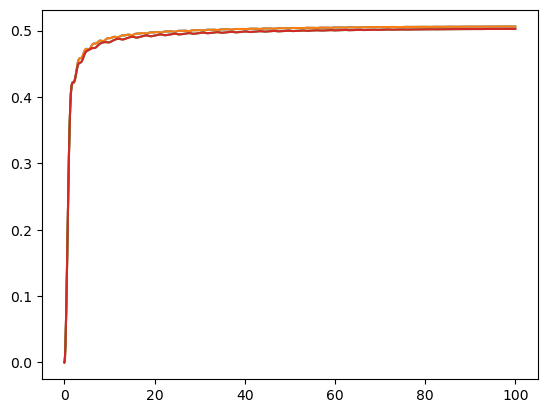

4-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f68a5da1340>
 PyObject <matplotlib.lines.Line2D object at 0x7f68a5da2660>
 PyObject <matplotlib.lines.Line2D object at 0x7f68a5da2a50>
 PyObject <matplotlib.lines.Line2D object at 0x7f68a5da2b70>

In [22]:
PyPlot.plot(sol.t, mapreduce(permutedims, vcat, [imag(diag(GL[t, t])) for t in eachindex(sol.t)]))
#PyPlot.ylim(-4,4)
# PyPlot.xlim(0.0,40)

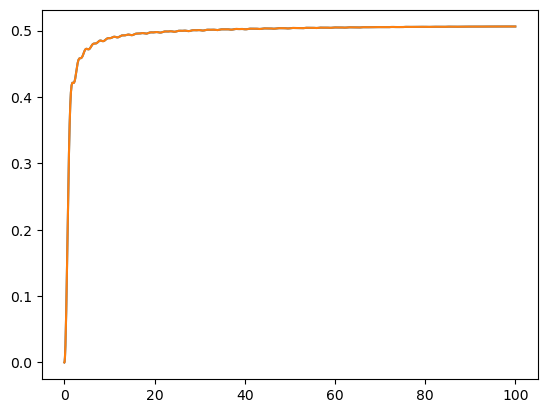

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f6898fbe630>

In [23]:
PyPlot.plot(sol.t, [imag(diag(GL[t, t])[1]) for t in eachindex(sol.t)] )
PyPlot.plot(sol.t, [imag(diag(GL[t, t])[2]) for t in eachindex(sol.t)] )

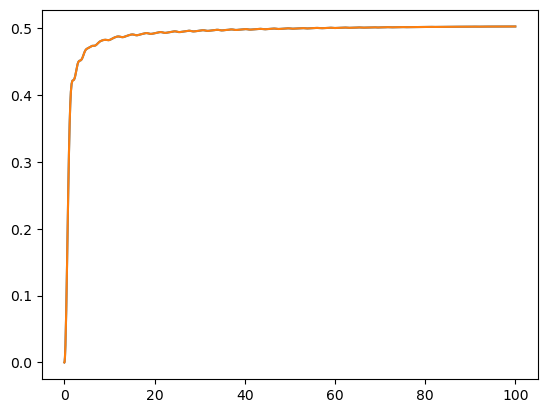

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f6899031c70>

In [24]:
PyPlot.plot(sol.t, [imag(diag(GL[t, t])[3]) for t in eachindex(sol.t)] )
PyPlot.plot(sol.t, [imag(diag(GL[t, t])[4]) for t in eachindex(sol.t)] )

In [25]:
#PyPlot.plt(
#diag(GL[40,40])

#length(sol.t)#GL
#sol.w

In [26]:
#sol.w[1]

In [27]:
### Calculation of the current 
# Auxiliary integrator for the first type of integral
function PI1(hs::Vector, t1, A::GreenFunction, B::GreenFunction)
    retval = zero(A[t1, t1])
    @inbounds for k in 1:t1
        @views LinearAlgebra.mul!(retval, A[t1, k] , B[k, t1], hs[k], 1.0)
    end
    return retval
end

∫dss(t,A, B) = PI1(sol.w[t], t, A, B)

Π(t) = ∫dss(t,GG, ΣL)- ∫dss(t,GL, ΣG)

Π (generic function with 1 method)

In [28]:
tss = 1:1:length(sol.t)
#tr(Π(2))
Π(1)[1:nσ,1:nσ]

2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

In [29]:
# ΣL_left = nothing
# ΣL_right = nothing

# ΣG_left = nothing
# ΣG_right = nothing

In [38]:

#ΣL[1,1]
size_t = length(sol.t)+1
Σ0L_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0L_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0L_left[1:2,1:2,:,:]=ΣL[1:2,1:2,:,:] 
Σ0L_right[3:4,3:4,:,:]=ΣL[3:4,3:4,:,:] 
ΣL_left = GreenFunction(Σ0L_left, SkewHermitian)
ΣL_right = GreenFunction(Σ0L_right, SkewHermitian)

#Σ0L_left


Σ0G_left = zeros(ComplexF64,4,4,size_t,size_t) #zero(ΣL) 
Σ0G_right = zeros(ComplexF64,4,4,size_t,size_t) 
Σ0G_left[1:2,1:2,:,:]=ΣG[1:2,1:2,:,:] 
Σ0G_right[3:4,3:4,:,:]=ΣG[3:4,3:4,:,:] 
ΣG_left = GreenFunction(Σ0G_left, SkewHermitian)
ΣG_right = GreenFunction(Σ0G_right, SkewHermitian)


4×4×568×568 GreenFunction{ComplexF64, 4, Array{ComplexF64, 4}, SkewHermitian}:
[:, :, 1, 1] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im       0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im       0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0-0.499934im  0.0-0.0im
 0.0+0.0im  0.0+0.0im  0.0-0.0im       0.0-0.499934im

[:, :, 2, 1] =
 0.0+0.0im  0.0+0.0im          0.0+0.0im               0.0+0.0im
 0.0+0.0im  0.0+0.0im          0.0+0.0im               0.0+0.0im
 0.0+0.0im  0.0+0.0im  -4.24278e-7-0.499934im         -0.0-0.0im
 0.0+0.0im  0.0+0.0im         -0.0-0.0im       -4.24278e-7-0.499934im

[:, :, 3, 1] =
 0.0+0.0im  0.0+0.0im          0.0+0.0im               0.0+0.0im
 0.0+0.0im  0.0+0.0im          0.0+0.0im               0.0+0.0im
 0.0+0.0im  0.0+0.0im  -2.54567e-6-0.499934im         -0.0-0.0im
 0.0+0.0im  0.0+0.0im         -0.0-0.0im       -2.54567e-6-0.499934im

;;; … 

[:, :, 566, 1] =
 0.0+0.0im  0.0+0.0im          0.0+0.0im                  0.0+0.0im
 0.0+0.0im  0.0+0.0im          0.0+0.0im         

In [39]:
Π_left(t) = ∫dss(t,GG, ΣL_left)- ∫dss(t,GL, ΣG_left)
Π_right(t) = ∫dss(t,GG, ΣL_right)- ∫dss(t,GL, ΣG_right)

Π_right (generic function with 1 method)

In [40]:
Curr_left= real(tr.(Π_left.(tss)))
Curr_right= real(tr.(Π_right.(tss)))

567-element Vector{Float64}:
  0.0
  9.998676757927677e-7
  5.999206054562776e-6
  3.0995897912571475e-5
  0.0001559793535910263
  0.000780896178363465
  0.0036550006015667203
  0.010058412807987005
  0.02198282245435739
  0.05026476733221573
  0.08477024371567936
  0.1251297956521865
  0.16035266387645752
  ⋮
 -0.007905166371544793
 -0.00790320629436617
 -0.007913340598245217
 -0.007926828936785245
 -0.007949501956114883
 -0.007959669242291263
 -0.007954714407136914
 -0.007936511548316722
 -0.00790988439202978
 -0.007886837410189121
 -0.007873365652570593
 -0.00787270038002173

In [1]:
plt.plot(sol.t, 4pi*Curr_left)
plt.plot(sol.t, 4pi*Curr_right)
plt.axhline(0.1,ls = "--",color="gray",lw=0.5)
plt.axhline(-0.1,ls = "--",color="gray",lw=0.5)
plt.ylim(-1,1)
plt.xlim(-1,60)
#plt.xlim(80,100)

LoadError: UndefVarError: `plt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [46]:
4pi*Curr_left[end-100]/0.05

1.9874070169873725

In [44]:
4pi*Curr_left[end]

0.10025943882734145

In [45]:
0.1/0.05
0.096742516300053/0.05

1.9348503260010599

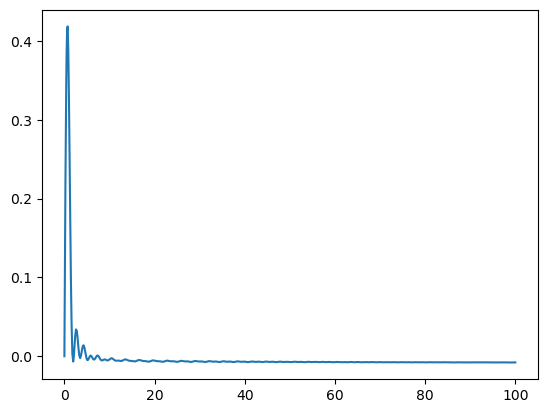

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f689906fa10>

In [47]:
plt.plot(sol.t, Curr_right)

In [83]:
0.05/0.2

0.25